# Impact of Covid-19 on Unemployment in India

* **Author:** Umer
* **Objective:** To analyze historical unemployment data, clean structural inconsistencies, and quantify the economic shock and recovery timeline of the 2020 Covid-19 pandemic across different regions and sectors in India.

## Step 1: Environment Setup

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling for the notebook
sns.set_theme(style="whitegrid")



## Step 2: Data Loading & Initial Inspection

In [13]:
# Load the datasets
df_general = pd.read_csv('Unemployment in India.csv')
df_covid = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')

# Inspect the first dataset
print("--- Unemployment in India.csv ---")
display(df_general.head())
print("\nInfo:")
df_general.info()

print("\n" + "="*50 + "\n")

# Inspect the second dataset
print("--- Unemployment_Rate_upto_11_2020.csv ---")
display(df_covid.head())
print("\nInfo:")
df_covid.info()

--- Unemployment in India.csv ---


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


--- Unemployment_Rate_upto_11_2020.csv ---


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


## Step 3: Data Cleaning

In [15]:
# Function to clean and preprocess the datasets robustly
def clean_data(df):
    # 1. Strip leading/trailing spaces from column names to prevent key errors
    df.columns = df.columns.str.strip()
    
    # 2. Drop rows where ALL elements are missing (handles the 28 blank rows in df_general)
    df.dropna(how='all', inplace=True)
    
    # 3. Strip whitespace from any string columns
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype(str).str.strip()
        
    # 4. Convert 'Date' column to proper pandas datetime objects
    # We specify dayfirst=True because the format is DD-MM-YYYY
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
    
    return df

# Apply the robust cleaning function to both datasets
df_general = clean_data(df_general)
df_covid = clean_data(df_covid)

# Verify the changes
print("--- Cleaned df_general Info ---")
df_general.info()
print("\n" + "="*50 + "\n")
print("--- Cleaned df_covid Info ---")
df_covid.info()

--- Cleaned df_general Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


--- Cleaned df_covid Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266


**Data Quality Assessment & Strategy**
Initial inspection of the datasets reveals several structural issues that must be addressed before analysis:
1. `df_general` contains 28 completely blank rows that will break time-series continuity.
2. Column names contain hidden leading spaces which will cause key errors during targeted analysis.
3. Date columns are currently stored as text strings rather than temporal objects.

The following robust cleaning function standardizes these elements across both datasets to ensure accurate aggregations and visualizations.

## Step 4: Exploratory Data Analysis (EDA) & Visualization.

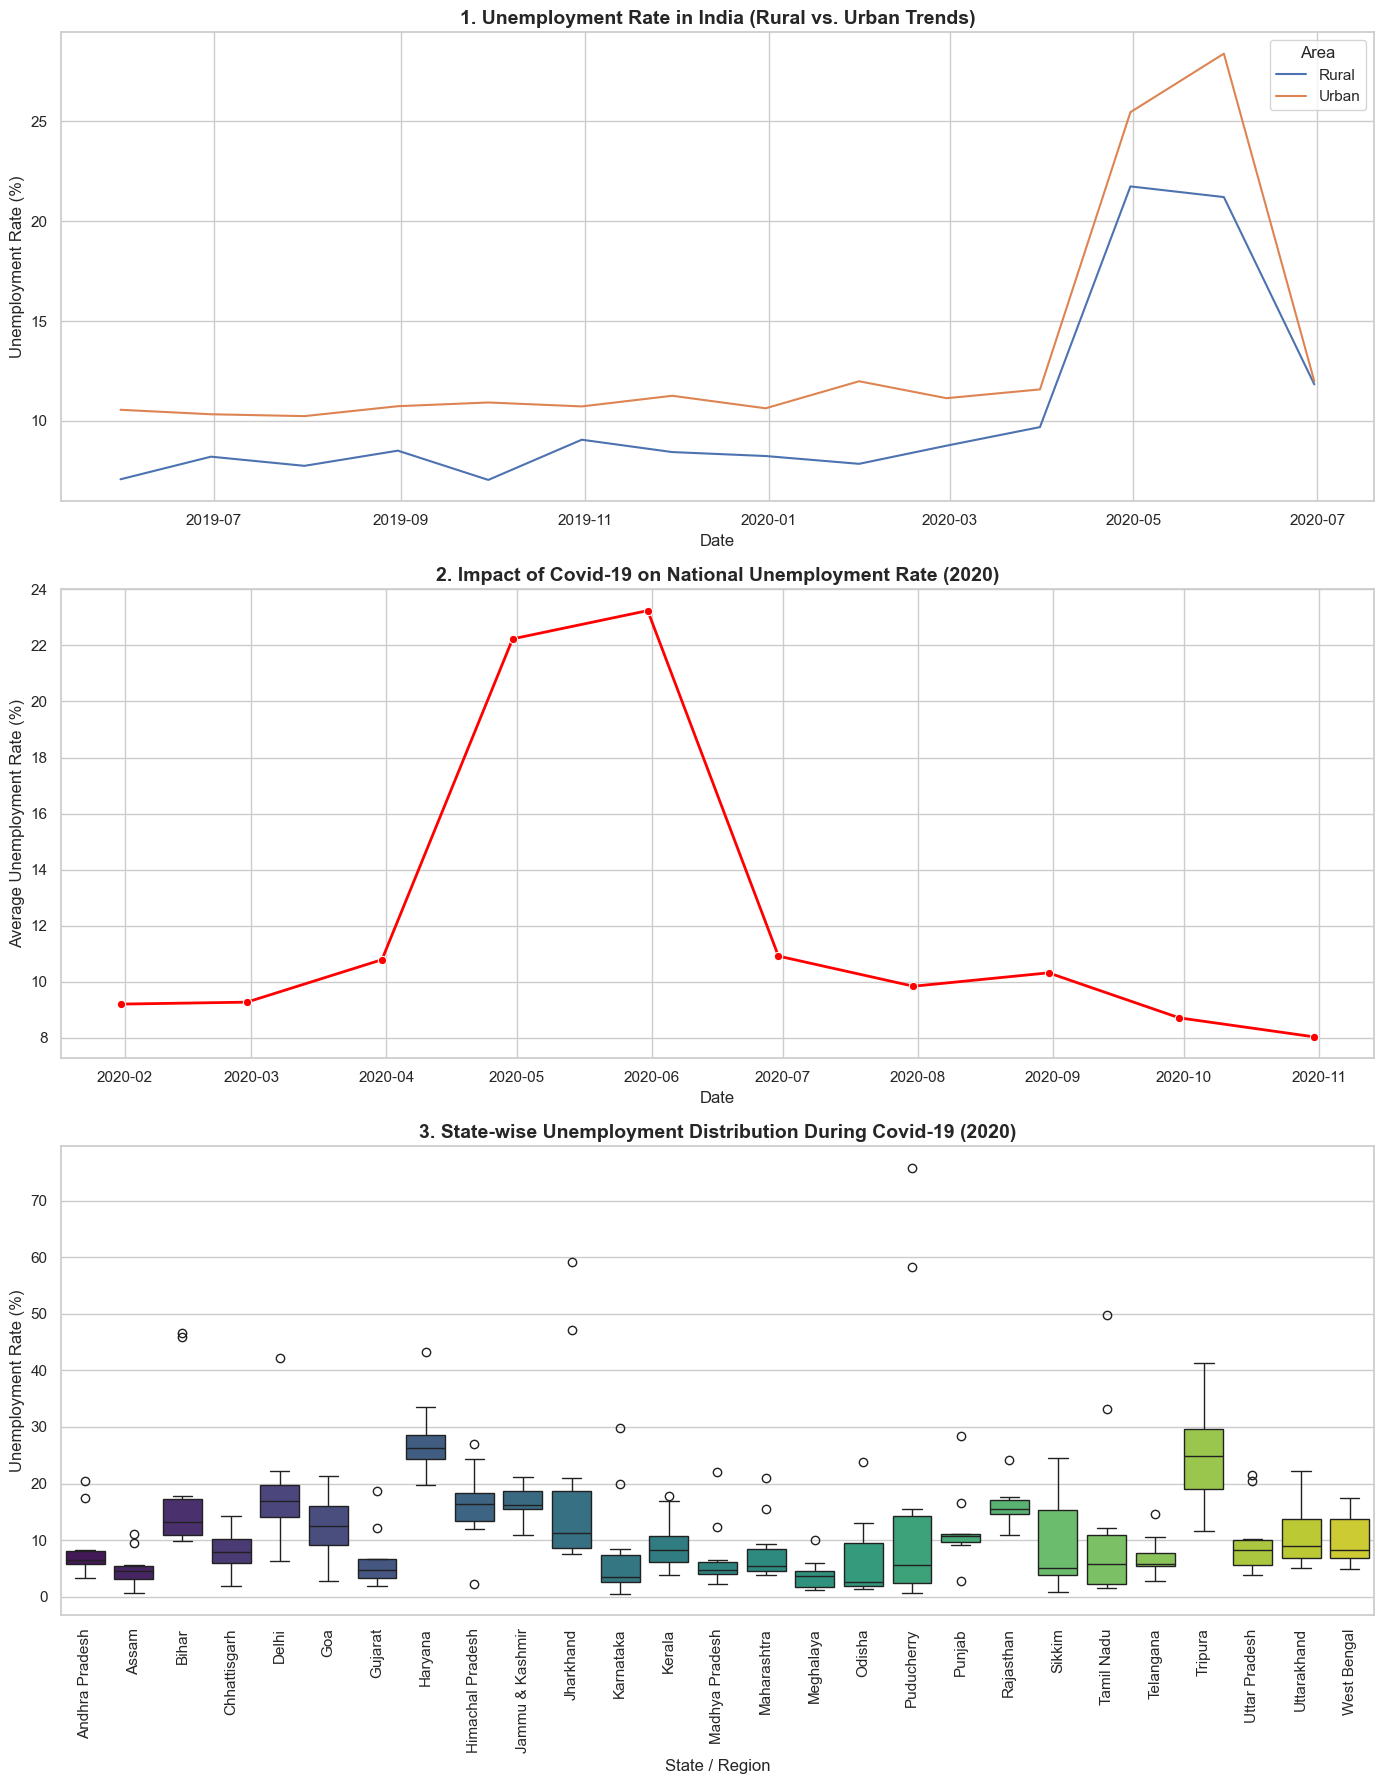

In [28]:
# Create a figure for multiple plots
plt.figure(figsize=(14, 18))

# --- Plot 1: Overall Trend (Rural vs. Urban) from df_general ---
plt.subplot(3, 1, 1)
sns.lineplot(data=df_general, x='Date', y='Estimated Unemployment Rate (%)', hue='Area', errorbar=None)
plt.title('1. Unemployment Rate in India (Rural vs. Urban Trends)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)

# --- Plot 2: The Covid-19 Impact (National Average over time) from df_covid ---
plt.subplot(3, 1, 2)
# Group by date to get the national average for each month
covid_trend = df_covid.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()
sns.lineplot(data=covid_trend, x='Date', y='Estimated Unemployment Rate (%)', marker='o', color='red', linewidth=2)
plt.title('2. Impact of Covid-19 on National Unemployment Rate (2020)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Unemployment Rate (%)', fontsize=12)

# --- Plot 3: State-wise Volatility during Covid from df_covid ---
plt.subplot(3, 1, 3)
sns.boxplot(data=df_covid, x='Region', y='Estimated Unemployment Rate (%)', hue='Region', legend=False, palette='viridis')
plt.title('3. State-wise Unemployment Distribution During Covid-19 (2020)', fontsize=14, fontweight='bold')
plt.xlabel('State / Region', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.xticks(rotation=90) # Rotate state names so they are readable

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

**Visualizing the Economic Shock**
The following visualizations are structured to isolate specific economic narratives from the data:
1. **Macro Trend:** Contrasting historical baseline unemployment between rural and urban sectors.
2. **Pandemic Shock:** Isolating the 2020 timeline to observe the speed and scale of the national V-shaped recovery.
3. **Micro Volatility:** Analyzing state-level distributions to identify extreme regional outliers during the crisis.

## Step 5: Key Insights & Conclusions

### Urban Vulnerability:
Urban areas experienced significantly higher unemployment peaks (~30%) during the 2020 lockdowns compared to rural areas (~22%), indicating a need for urban-focused economic relief during systemic shocks.

### The Covid-19 Shock:
The national unemployment rate saw a dramatic V-shaped trajectory, spiking to nearly 24% in May 2020 before rapidly recovering to pre-pandemic levels by July.

### State-Level Disparities:
The pandemic's impact was highly localized. While the national average spiked, the boxplot reveals massive outliers in states like Puducherry and Jharkhand (exceeding 50-70%), highlighting the necessity for localized, state-specific economic policies rather than a single national approach.